06-06-26

In [1]:
# import libraries

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [2]:
# create a 1-qubit circuit and apply a Hadamard gate

qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()

In [3]:
# run the circuit 1000 times on a simulator

simulator = AerSimulator()
result = simulator.run(qc, shots = 1000).result()
counts = result.get_counts()

In [4]:
# display counts

counts

{'0': 498, '1': 502}

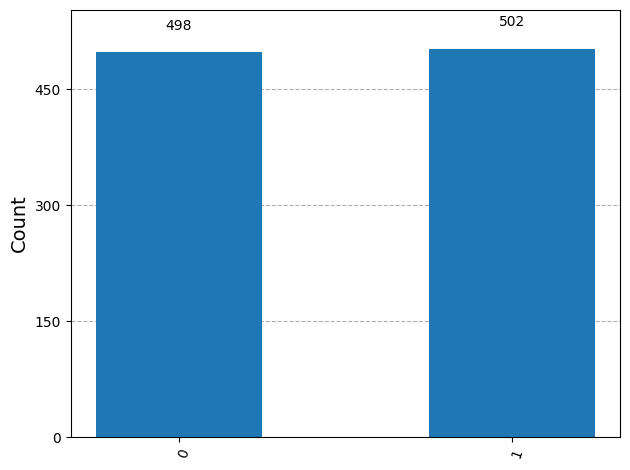

In [5]:
# create a simple bar chart of the results

plot_histogram(counts)

---

11-06-26

## Lab 1

In [6]:
import qiskit

In [7]:
qiskit.__version__

'2.4.1'

Matrix and Vector Comuputation with Numpy

In [8]:
from numpy import array

ket0 = array([1, 0])
ket1 = array([0, 1])

display(ket0 / 2 + ket1 / 2)

array([0.5, 0.5])

In [9]:
M1 = array([[1, 1], [0, 0]])
M2 = array([[1, 1], [1, 0]])

M1 / 2 + M2 / 2

array([[1. , 1. ],
       [0.5, 0. ]])

In [10]:
from numpy import matmul

display(matmul(M1, ket1))
display(matmul(M1, M2))
display(matmul(M2, M1))

array([1, 0])

array([[2, 1],
       [0, 0]])

array([[1, 1],
       [1, 1]])

Defining and Validating State Vectors in Qiskit

In [11]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1/sqrt(2), 1/sqrt(2)])
v = Statevector([(1+2.0j)/3, -2/3])
w = Statevector([1/3, 2/3])

print("State vectors u, v, and w have been defined.")

State vectors u, v, and w have been defined.


In [12]:
display(u.draw("latex"))
display(v.draw("text"))

<IPython.core.display.Latex object>

[ 0.33333333+0.66666667j,-0.66666667+0.j        ]

In [13]:
display(u.is_valid())
display(w.is_valid())

True

False

Simulating Quantum Measurements

In [14]:
v = Statevector([(1+2.0j)/3, -2/3])
v.draw("latex")
v.measure()

(np.str_('0'),
 Statevector([0.4472136+0.89442719j, 0.       +0.j        ],
             dims=(2,)))

Sampling Measurement and Plotting Histograms

{np.str_('0'): np.int64(547), np.str_('1'): np.int64(453)}

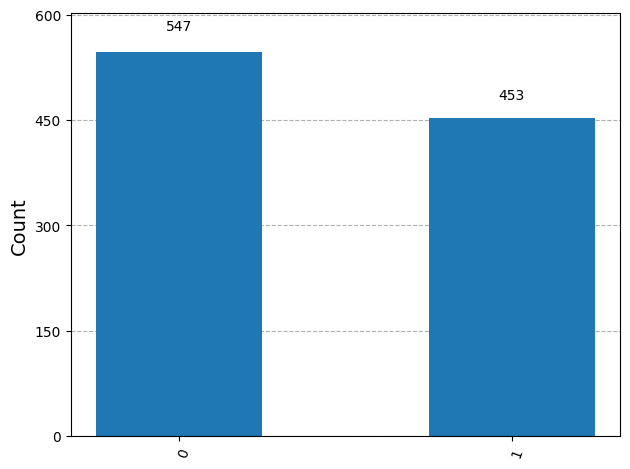

In [15]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
display(statistics)
plot_histogram(statistics)

---

## Lab 2

Performing operations with Operator and State vector

In [16]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from numpy import sqrt

X = Operator([[0, 1], [1, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
Z = Operator([[1, 0], [0, -1]])
H = Operator([[1/sqrt(2), 1/sqrt(2)], [1/sqrt(2), -1/sqrt(2)]])
s = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

v = Statevector([1, 0])
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(Z)

display(v.draw("text"))
display(v.draw("latex"))

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

<IPython.core.display.Latex object>

Creating and Visualizing Quantum Circuits

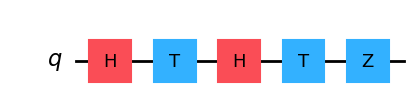

In [17]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)
circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.t(0)
circuit.z(0)

display(circuit.draw(output='mpl'))

Simulating Circuit Evolution and Measurement Sampling

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

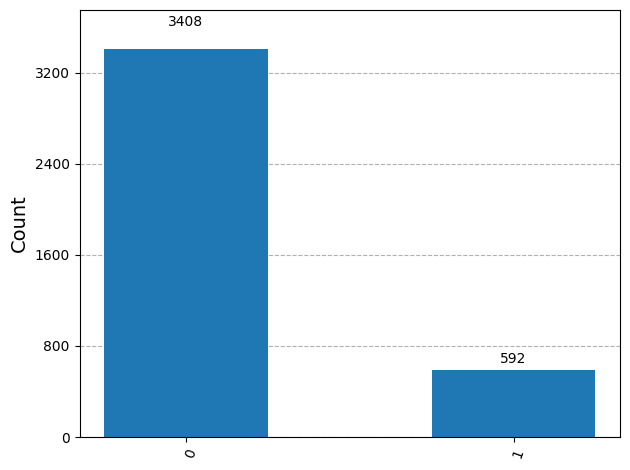

In [18]:
from qiskit.visualization import plot_histogram

ket = Statevector([1, 0])
v = ket.evolve(circuit)
display(v.draw("text"))

statistics = v.sample_counts(4000)
plot_histogram(statistics)

---

22-06-26

## Lab 3

In [1]:
from qiskit.quantum_info import Statevector, Operator
from numpy import  sqrt

Tensor products

The state vector class has a tensor method which returns the tensor product of itslef and another StateVector

For example, below we create 2 vectors representing |0> and |1>, and use the tensor method to create a new vector

In [2]:
zero, one = Statevector.from_label("0"), Statevector.from_label("1")
zero.tensor(one).draw("latex")

<IPython.core.display.Latex object>

In another example below, we create state vectors representing the |+> and 1/root 2 (|0> + i|1>) states, and combine them to create a new state vector

We'll assign this new vector to the variable psi

In [3]:
plus = Statevector.from_label("+")
i_state = Statevector([1 / sqrt(2), 1j / sqrt(2)])
psi = plus.tensor(i_state)

psi.draw("latex")

<IPython.core.display.Latex object>

The Operator class also has a tensor method

In the example below, we create the X and I gates and display their tensor product

In [5]:
X = Operator([[0, 1], [1, 0]])
I = Operator([[1, 0], [0, 1]])

X.tensor(I)

Operator([[0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


We can treat these compound states and operations as we did single systems in the previous lesson

For the state psi we defined above

The ^ operator tensors matrices together

In [6]:
psi.evolve(I ^ X).draw("latex)

SyntaxError: unterminated string literal (detected at line 1) (809700575.py, line 1)